In [5]:
import pandas as pd

# Load dataset
df = pd.read_csv('../data/raw/student_data.csv')

# Show first 5 rows
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   student_id               1000000 non-null  int64  
 1   weekly_self_study_hours  1000000 non-null  float64
 2   attendance_percentage    1000000 non-null  float64
 3   class_participation      1000000 non-null  float64
 4   total_score              1000000 non-null  float64
 5   grade                    1000000 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 45.8+ MB


In [7]:
df.isnull().sum()

student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64

In [8]:
df = df.drop('student_id', axis=1)

In [9]:
df = df.drop('grade', axis=1)

In [10]:
df.duplicated().sum()

np.int64(17871)

In [11]:
df = df.drop_duplicates()

In [12]:
df.head()
df.describe()

,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,982129.000000,982129.000000,982129.000000,982129.000000
mean,14.904520,84.572043,5.982182,84.008209
std,6.880522,9.374755,1.961752,15.426189
min,0.000000,50.000000,0.000000,9.400000
25%,10.200000,78.200000,4.600000,73.600000
50%,14.800000,84.900000,6.000000,87.000000
75%,19.500000,91.600000,7.400000,100.000000
max,40.000000,100.000000,10.000000,100.000000


In [13]:
df.to_csv('../data/processed/cleaned_student_data.csv', index=False)

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

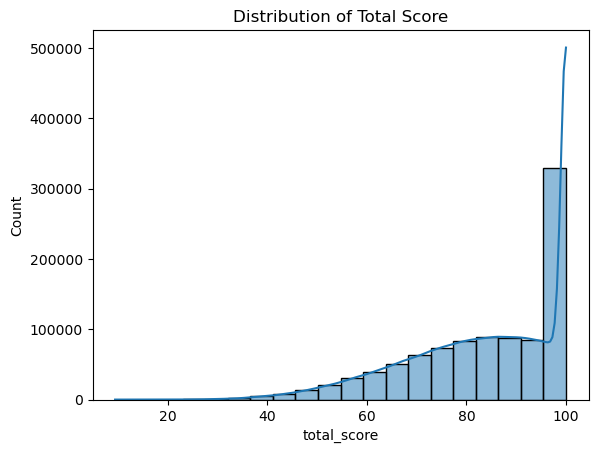

In [15]:
sns.histplot(df['total_score'], bins=20, kde=True)
plt.title("Distribution of Total Score")
plt.show()

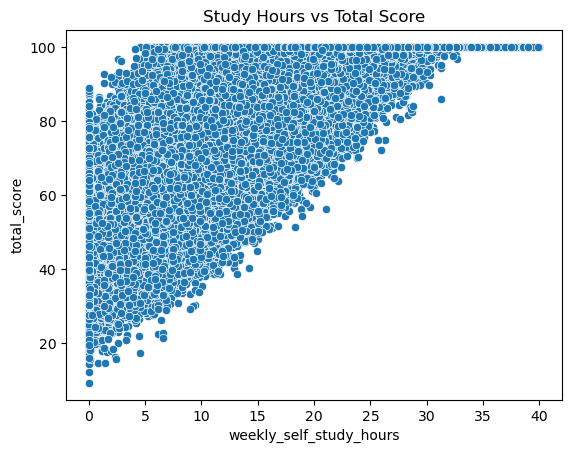

In [16]:
sns.scatterplot(x='weekly_self_study_hours', y='total_score', data=df)
plt.title("Study Hours vs Total Score")
plt.show()

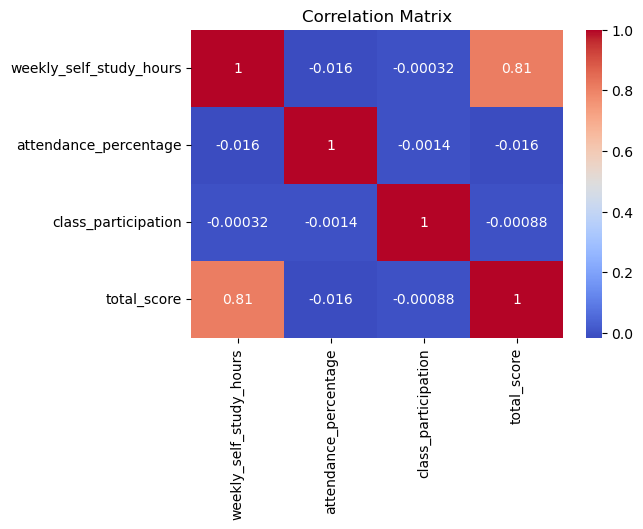

In [17]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

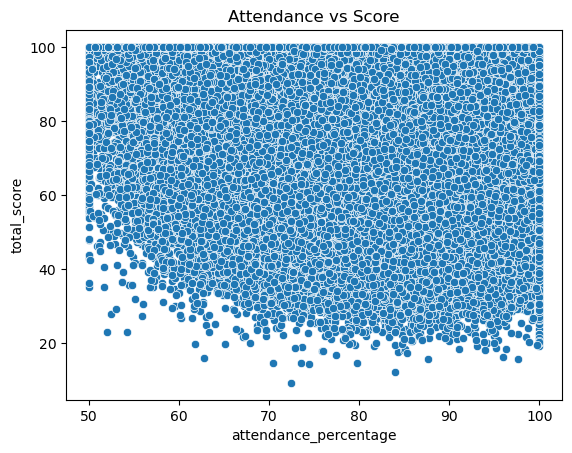

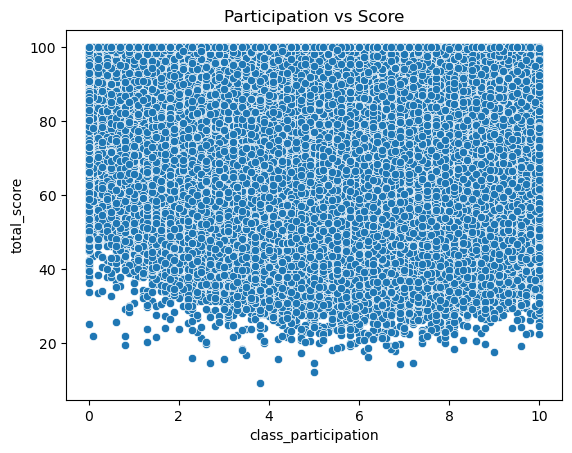

In [18]:
sns.scatterplot(x='attendance_percentage', y='total_score', data=df)
plt.title("Attendance vs Score")
plt.show()

sns.scatterplot(x='class_participation', y='total_score', data=df)
plt.title("Participation vs Score")
plt.show()

1. Students who study more tend to score higher.
2. Attendance has a moderate positive impact on scores.
3. Class participation also improves performance.
4. Study hours show the strongest correlation with total_score.

In [19]:
X = df.drop('total_score', axis=1)
y = df['total_score']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 81.6666415552108
R2 Score: 0.6579377783167701


In [30]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=50,   # reduce trees (default = 100)
    max_depth=10,      # limit tree depth
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, y_pred_rf))

R2 Score: 0.7144334243685692


In [33]:
import pickle

with open('../models/student_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

FileNotFoundError: [Errno 2] No such file or directory: '../models/student_model.pkl'

In [34]:
import os
import pickle

os.makedirs('../models', exist_ok=True)

with open('../models/student_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

In [35]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,50
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
import os
import pickle

os.makedirs('../models', exist_ok=True)

with open('../models/student_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

In [37]:
rf.predict(X_test[:2])

array([88.68 , 96.228])